*   REVANTH SAI BOMMA
*   1/23/SET/BCS/417
*   6AIMLB1
*   DATE: 16/04/2026
*   EXPERIMENT: 11



Base RNN

Step-by-step RNN computation:

Time step 1:
Input x_1 = 1.0
h_1 = tanh(0.5*1.0 + 0.8*0.0) = 0.4621

Final Hidden States: [np.float64(0.46211715726000974)]
Time step 2:
Input x_2 = 2.0
h_2 = tanh(0.5*2.0 + 0.8*0.46211715726000974) = 0.8786

Final Hidden States: [np.float64(0.46211715726000974), np.float64(0.8786223746838898)]
Time step 3:
Input x_3 = 3.0
h_3 = tanh(0.5*3.0 + 0.8*0.8786223746838898) = 0.9759

Final Hidden States: [np.float64(0.46211715726000974), np.float64(0.8786223746838898), np.float64(0.9758816208890569)]


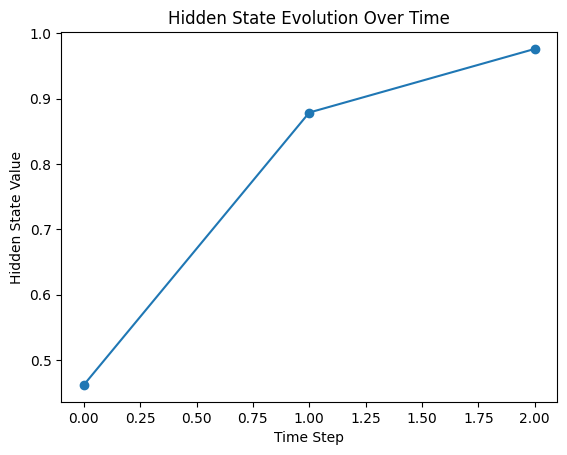

In [1]:
import numpy as np
# Sequence: x1, x2, x3
X = [1.0, 2.0, 3.0]
# Weight matrices (scalar case for simplicity)
Wx = 0.5   # input weight
Wh = 0.8   # hidden weight
b = 0.0    # bias

# Initial hidden state
h_prev = 0.0
def tanh(x):
    return np.tanh(x)
hidden_states = []

print("Step-by-step RNN computation:\n")

for t, x_t in enumerate(X):
    h_t = tanh(Wx * x_t + Wh * h_prev + b)

    print(f"Time step {t+1}:")
    print(f"Input x_{t+1} = {x_t}")
    print(f"h_{t+1} = tanh({Wx}*{x_t} + {Wh}*{h_prev}) = {h_t:.4f}\n")

    hidden_states.append(h_t)
    h_prev = h_t
    print("Final Hidden States:", hidden_states)

import matplotlib.pyplot as plt

plt.plot(hidden_states, marker='o')
plt.title("Hidden State Evolution Over Time")
plt.xlabel("Time Step")
plt.ylabel("Hidden State Value")
plt.show()

After Changing number of inputs and Activation Function

Step-by-step RNN computation:

Time step 1:
Input x_1 = 1.0
h_1 = sigmoid(0.3*1.0 + 0.6*0.0 + 0.2) = 0.6225

Time step 2:
Input x_2 = 2.0
h_2 = sigmoid(0.3*2.0 + 0.6*0.6224593312018546 + 0.2) = 0.7638

Time step 3:
Input x_3 = 3.0
h_3 = sigmoid(0.3*3.0 + 0.6*0.763772671855798 + 0.2) = 0.8261

Time step 4:
Input x_4 = 4.0
h_4 = sigmoid(0.3*4.0 + 0.6*0.8261040501214199 + 0.2) = 0.8694

Time step 5:
Input x_5 = 5.0
h_5 = sigmoid(0.3*5.0 + 0.6*0.8693998101958481 + 0.2) = 0.9022

Time step 6:
Input x_6 = 6.0
h_6 = sigmoid(0.3*6.0 + 0.6*0.9021760184315819 + 0.2) = 0.9270

Time step 7:
Input x_7 = 7.0
h_7 = sigmoid(0.3*7.0 + 0.6*0.9269872420856028 + 0.2) = 0.9456

Time step 8:
Input x_8 = 8.0
h_8 = sigmoid(0.3*8.0 + 0.6*0.9456378917190646 + 0.2) = 0.9596

Final Hidden States: [np.float64(0.6224593312018546), np.float64(0.763772671855798), np.float64(0.8261040501214199), np.float64(0.8693998101958481), np.float64(0.9021760184315819), np.float64(0.9269872420856028), np.float64(0.945637891719064

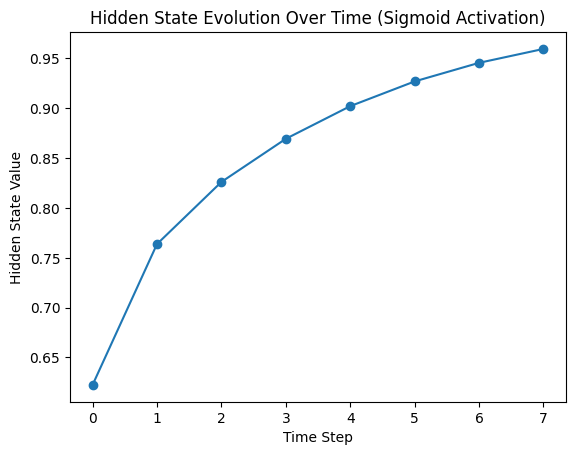

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Updated Sequence: x1 to x8
X = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]

# Updated Weight values
Wx = 0.3   # input weight
Wh = 0.6   # hidden weight
b = 0.2    # bias

# Initial hidden state
h_prev = 0.0

# Sigmoid activation function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

hidden_states = []

print("Step-by-step RNN computation:\n")

for t, x_t in enumerate(X):
    h_t = sigmoid(Wx * x_t + Wh * h_prev + b)

    print(f"Time step {t+1}:")
    print(f"Input x_{t+1} = {x_t}")
    print(f"h_{t+1} = sigmoid({Wx}*{x_t} + {Wh}*{h_prev} + {b}) = {h_t:.4f}\n")

    hidden_states.append(h_t)
    h_prev = h_t

print("Final Hidden States:", hidden_states)

# Plotting
plt.plot(hidden_states, marker='o')
plt.title("Hidden State Evolution Over Time (Sigmoid Activation)")
plt.xlabel("Time Step")
plt.ylabel("Hidden State Value")
plt.show()

BPTT Implementation

In [2]:
import numpy as np

# -------------------------
# 1. Input sequence
# -------------------------
X = [1.0, 2.0, 3.0]
target = 0.5   # desired output

# -------------------------
# 2. Initialize parameters
# -------------------------
Wx = 0.5
Wh = 0.8
Wy = 1.0
b = 0.0

# Learning rate
lr = 0.01

# -------------------------
# 3. Activation functions
# -------------------------
def tanh(x):
    return np.tanh(x)

def dtanh(x):
    return 1 - np.tanh(x)**2

# -------------------------
# 4. Forward Pass
# -------------------------
h = [0.0]   # h0 = 0

for t in range(len(X)):
    h_t = tanh(Wx * X[t] + Wh * h[t] + b)
    h.append(h_t)

# Output (many-to-one)
y_pred = Wy * h[-1]

# Loss (Mean Squared Error)
loss = 0.5 * (y_pred - target)**2

print("Forward Pass:")
print("Hidden states:", h[1:])
print("Prediction:", y_pred)
print("Loss:", loss)

# -------------------------
# 5. Backward Pass (BPTT)
# -------------------------

# Gradients initialization
dWx = 0
dWh = 0
dWy = 0
db = 0

# Output gradient
dy = (y_pred - target)

# Gradient for Wy
dWy = dy * h[-1]

# Backprop through time
dh_next = dy * Wy   # gradient flowing into last hidden state

for t in reversed(range(len(X))):

    # derivative of tanh
    dt = dtanh(Wx * X[t] + Wh * h[t] + b)

    # current gradient
    dh = dh_next * dt
    print(f"\nTime step {t}")
    print("dh:", dh)
    # accumulate gradients
    dWx += dh * X[t]
    dWh += dh * h[t]
    db  += dh

    # pass gradient backward in time
    dh_next = dh * Wh
      # PRINT AFTER UPDATING dh_next
    print("dh_next:", dh_next)
print("\nGradients:")
print("dWx:", dWx)
print("dWh:", dWh)
print("dWy:", dWy)
print("db:", db)

# -------------------------
# 6. Update weights
# -------------------------
Wx -= lr * dWx
Wh -= lr * dWh
Wy -= lr * dWy
b  -= lr * db

print("\nUpdated Parameters:")
print("Wx:", Wx)
print("Wh:", Wh)
print("Wy:", Wy)
print("b:", b)



Forward Pass:
Hidden states: [np.float64(0.46211715726000974), np.float64(0.8786223746838898), np.float64(0.9758816208890569)]
Prediction: 0.9758816208890569
Loss: 0.11323165854999806

Time step 2
dh: 0.02267816815333795
dh_next: 0.01814253452267036

Time step 1
dh: 0.0041369101186258935
dh_next: 0.003309528094900715

Time step 0
dh: 0.0026027708674217116
dh_next: 0.0020822166939373694

Gradients:
dWx: 0.07891109556468734
dWh: 0.02183728310022592
dWy: 0.4644041275445246
db: 0.029417849139385555

Updated Parameters:
Wx: 0.4992108890443531
Wh: 0.7997816271689978
Wy: 0.9953559587245547
b: -0.00029417849139385554


After adding the graph for vanishing gradients and exploding gradients

Forward Pass:
Hidden states: [np.float64(0.8853516482022624), np.float64(0.9976014640840131), np.float64(0.9996968394197514), np.float64(0.9999501329536864), np.float64(0.9999917618706265), np.float64(0.9999986383777372), np.float64(0.9999997749289404), np.float64(0.999999962796102)]
Prediction: 1.0999999590757124
Loss: 0.17999997544542826

Time step 7
dh: 4.910914108141975e-08
dh_next: 5.893096929770369e-08

Time step 6
dh: 2.6527308418896715e-14
dh_next: 3.1832770102676054e-14

Time step 5
dh: 8.668835790197002e-20
dh_next: 1.0402602948236402e-19

Time step 4
dh: 1.7139527182479484e-24
dh_next: 2.056743261897538e-24

Time step 3
dh: 2.0512230844318373e-28
dh_next: 2.4614677013182045e-28

Time step 2
dh: 1.49221372870848e-31
dh_next: 1.790656474450176e-31

Time step 1
dh: 8.579606133218618e-34
dh_next: 1.0295527359862341e-33

Time step 0
dh: 2.2254035557989436e-34
dh_next: 2.670484266958732e-34

Gradients:
dWx: 3.92873314343037e-07
dWh: 4.910915655573232e-08
dWy: 0.5999999367533752
db

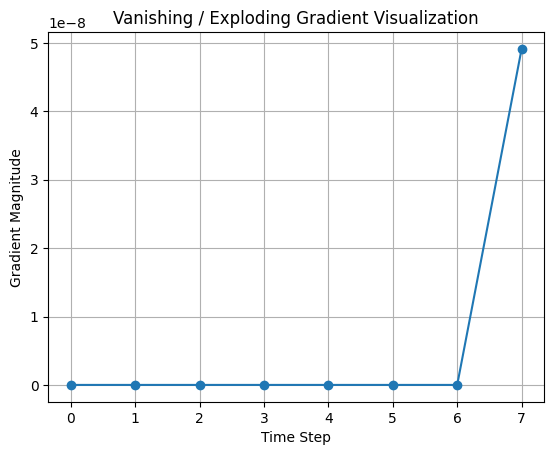

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# 1. Input sequence
# -------------------------
X = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]
target = 0.5   # desired output

# -------------------------
# 2. Initialize parameters
# -------------------------
Wx = 0.9
Wh = 1.2
Wy = 1.1
b = 0.5

# Learning rate
lr = 0.01

# -------------------------
# 3. Activation functions
# -------------------------
def tanh(x):
    return np.tanh(x)

def dtanh(x):
    return 1 - np.tanh(x)**2

# -------------------------
# 4. Forward Pass
# -------------------------
h = [0.0]   # h0 = 0

for t in range(len(X)):
    h_t = tanh(Wx * X[t] + Wh * h[t] + b)
    h.append(h_t)

# Output (many-to-one)
y_pred = Wy * h[-1]

# Loss (Mean Squared Error)
loss = 0.5 * (y_pred - target)**2

print("Forward Pass:")
print("Hidden states:", h[1:])
print("Prediction:", y_pred)
print("Loss:", loss)

# -------------------------
# 5. Backward Pass (BPTT)
# -------------------------

# Gradients initialization
dWx = 0
dWh = 0
dWy = 0
db = 0

# Store gradients for graph
gradients = []

# Output gradient
dy = (y_pred - target)

# Gradient for Wy
dWy = dy * h[-1]

# Backprop through time
dh_next = dy * Wy   # gradient flowing into last hidden state

for t in reversed(range(len(X))):

    # derivative of tanh
    dt = dtanh(Wx * X[t] + Wh * h[t] + b)

    # current gradient
    dh = dh_next * dt
    gradients.append(abs(dh))   # store magnitude

    print(f"\nTime step {t}")
    print("dh:", dh)

    # accumulate gradients
    dWx += dh * X[t]
    dWh += dh * h[t]
    db  += dh

    # pass gradient backward in time
    dh_next = dh * Wh

    print("dh_next:", dh_next)

print("\nGradients:")
print("dWx:", dWx)
print("dWh:", dWh)
print("dWy:", dWy)
print("db:", db)

# -------------------------
# 6. Update weights
# -------------------------
Wx -= lr * dWx
Wh -= lr * dWh
Wy -= lr * dWy
b  -= lr * db

print("\nUpdated Parameters:")
print("Wx:", Wx)
print("Wh:", Wh)
print("Wy:", Wy)
print("b:", b)

# -------------------------
# 7. Plot Vanishing / Exploding Gradient
# -------------------------
gradients = gradients[::-1]  # reverse to match time order

plt.figure()
plt.plot(range(len(gradients)), gradients, marker='o')
plt.title("Vanishing / Exploding Gradient Visualization")
plt.xlabel("Time Step")
plt.ylabel("Gradient Magnitude")
plt.grid()

plt.show()

Application of RNN using IMDB Dataset

In [16]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense


vocab_size = 5000
max_len = 200
embed_size=32
hidden_size=128

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embed_size, input_length=max_len),
    SimpleRNN(hidden_size),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    verbose=1
)

loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy*100:.2f}%")

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 22s 52ms/step - accuracy: 0.6233 - loss: 0.6340
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - accuracy: 0.7157 - loss: 0.5709
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.7752 - loss: 0.4787
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.8299 - loss: 0.3979
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.8246 - loss: 0.4048
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.7075 - loss: 0.5536
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.8179 - loss: 0.4109
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 51ms/step - accuracy: 0.7796 - loss: 0.4653
Epoch 9/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.7588 - loss: 0.4901
Epoch 10/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.8402 - loss: 0.3872
Epoch 11/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.8019 - loss: 0.4233
Epoch 12/20
391/391 ━━━━━━━━━━